eps = 134
TSVD keeps 1000/1000 singular values (tau = 1e-15)
relative L2 error = 1.025e-06


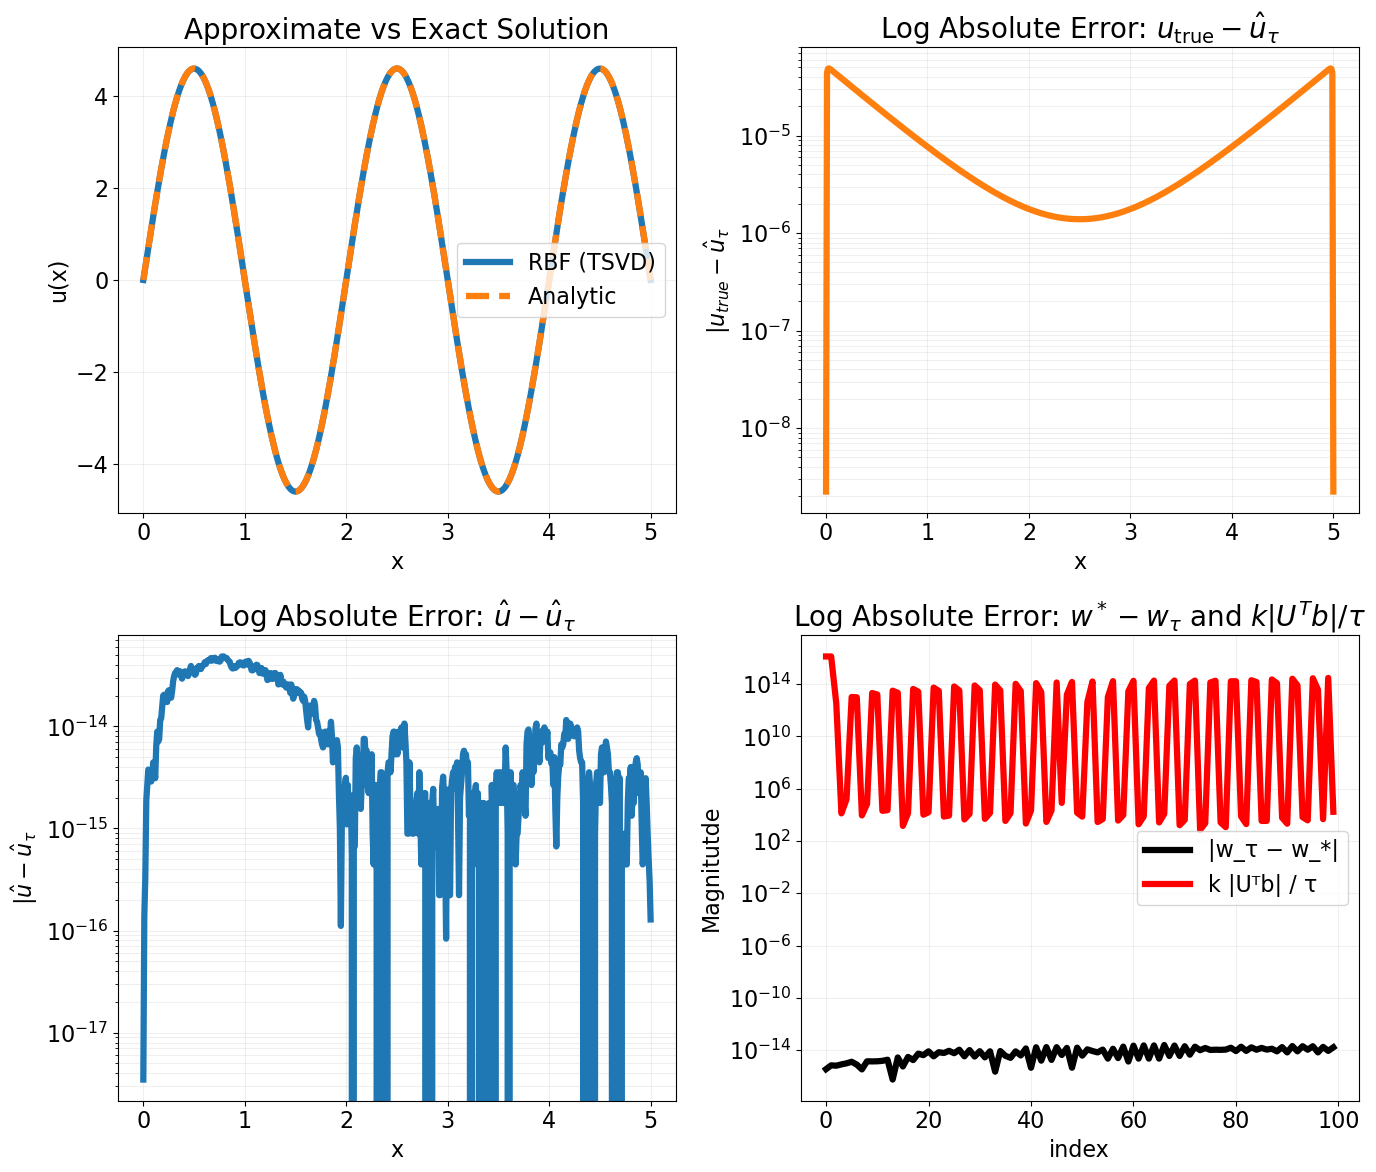

In [ ]:
"""
Variational Gaussian-RBF solver for 1-D Helmholtz‐type BVP
   -u'' + u = sin(pi x / L),  u(0)=u(L)=0
using a truncated SVD (TSVD) pseudo-inverse.

Author: <your-name>
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.linalg import svd, lstsq, norm

# ---------------------------------------------------------------------
# 1.  Problem & numerical parameters
# ---------------------------------------------------------------------
L     = 5.0          # domain length
Amplitude = 50.0 # amplitude solution. 
N     = 1000          # number of RBF centres
T     = 2            # oversampling factor for quadrature
beta  = 3e5          # Dirichlet penalty weight
tau   = 1e-15        # TSVD relative threshold (σ_i > tau*σ_max kept)

# ---- shape parameter -------------------------------------------------
h      = L / N                   # nominal fill distance
#eps    = 2.0 / h                 # good rule-of-thumb scaling
eps = 0.134 * N                # <- original extremely narrow kernel
print(f"eps = {eps:.3g}")

# ---------------------------------------------------------------------
# 2.  RBF kernel & derivative
# ---------------------------------------------------------------------
def gaussian_rbf(r, eps):
    return np.exp(-(eps * r) ** 2)

def d_gaussian_rbf(r, eps):
    return -2.0 * eps**2 * r * np.exp(-(eps * r) ** 2)

def assemble_basis(x_eval, centers, eps, deriv=0):
    """Return Φ or Φ_x  (shape len(x_eval) × len(centers))."""
    r = cdist(x_eval[:, None], centers[:, None])
    if deriv == 0:
        return gaussian_rbf(r, eps)
    elif deriv == 1:
        diff  = x_eval[:, None] - centers[None, :]
        return d_gaussian_rbf(np.abs(diff), eps) * np.sign(diff)
    else:
        raise ValueError("deriv must be 0 or 1")

# ---------------------------------------------------------------------
# 3.  Collocation / quadrature setup
# ---------------------------------------------------------------------
centers = np.linspace(0.0, L, N)
M       = T * N                                # quadrature points
x_quad  = np.linspace(0.0, L, M)
dx      = L / (M - 1)

Phi     = assemble_basis(x_quad, centers, eps, deriv=0)
Phi_x   = assemble_basis(x_quad, centers, eps, deriv=1)

f_vec   = Amplitude * np.sin(np.pi * x_quad )           # forcing term

# ---------------------------------------------------------------------
# 4.  Assemble stiffness + mass + penalty   (A w = b)
# ---------------------------------------------------------------------
A_core  = (Phi_x.T @ Phi_x + Phi.T @ Phi) * dx
b_core  = (Phi.T @ f_vec) * dx

# two rows for Dirichlet BC penalty
P0      = gaussian_rbf(np.abs(centers - 0.0), eps)
PL      = gaussian_rbf(np.abs(centers - L  ), eps)
P       = np.vstack([P0, PL])                  # 2 × N

A_pen   = 2.0 * (beta / 2) * (P.T @ P)               # 2 * (beta / 2) *  P^T P 
# b_pen remains zero for homogeneous BC

A       = A_core + A_pen
b       = b_core.copy()

# ---------------------------------------------------------------------
# 5.  Truncated-SVD pseudo-inverse solve
# ---------------------------------------------------------------------
U, s, Vt = svd(A, full_matrices=False)
sigma_max = s[0]
mask      = s > tau * sigma_max                # keep “large” σ
k         = mask.sum()
print(f"TSVD keeps {k}/{len(s)} singular values (tau = {tau})")

s_inv            = np.zeros_like(s)
s_inv[mask]      = 1.0 / s[mask]
A_tsvd_inv       = (Vt.T * s_inv) @ U.T        # V Sigma_inv * U^T 
w_tsvd           = A_tsvd_inv @ b

# ------------------------------------------------------------------ #
# 4.  direct least-squares solution  (w*)
# ------------------------------------------------------------------ #
w_star, *_ = lstsq(A, b, rcond=None)

# 1. Compute the threshold
threshold = tau * sigma_max

# 2. Find all i for which S[i] > threshold
retained = np.where(s > threshold)[0]

# 3. The number of retained modes is k
k = retained.size

# 4. If you want the largest retained index (0‐based):
k_max_index = retained.max()  # so modes 0..k_max_index are kept




# ---------------------------------------------------------------------
# 6.  Evaluate & compare
# ---------------------------------------------------------------------
x_plot  = np.linspace(0.0, L, 512)
Phi_pl  = assemble_basis(x_plot, centers, eps, deriv=0)


u_star  = Phi_pl @ w_star
u_rbf   = Phi_pl @ w_tsvd
u_exact = Amplitude * np.sin(np.pi * x_plot ) / (1.0 + (np.pi) ** 2)


rel_L2  = norm(u_rbf - u_exact) ** 2 / norm(u_exact)**2
print(f"relative L2 error = {rel_L2:.3e}")

# errors
abs_err_ref = np.abs(u_rbf - u_exact) ** 2 
abs_err_ws  = np.abs(u_star - u_rbf)
coeff_diff  = np.abs(w_tsvd - w_star)
proj_ratio  = np.abs(U.T @ b) / tau



# ---------------------------------------------------------------------
# 7.  Plot
# ---------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.2,
    "figure.dpi": 300
})


# Font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16
linewidth = 4.5



# ------------------------------------------------------------------ #
# 7.  4-panel diagnostic plot
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
#fig.suptitle(f'Gaussian RBF   N={N},  ε={eps:.3g},  τ={tau}', fontsize=14)

# ── top-left: numerical vs reference
ax[0, 0].plot(x_plot, u_rbf, label='RBF (TSVD)')
ax[0, 0].plot(x_plot, u_exact, '--', label='Analytic')
ax[0, 0].set(title='Approximate vs Exact Solution', xlabel='x', ylabel='u(x)')
ax[0, 0].grid(); ax[0, 0].legend(loc = 'best')

# ── top-right: |u_τ − u_ref|
ax[0, 1].semilogy(x_plot, abs_err_ref, color = 'tab:orange')
ax[0, 1].set(title=r'Log Absolute Error: $u_{\mathrm{true}} - \hat{u}_{\tau}$', xlabel='x', ylabel=r'$|u_{true} - \hat{u}_{\tau}$')

ax[0, 1].grid(which='both')

# ── bottom-left: |u* − u_τ|
ax[1, 0].semilogy(x_plot, abs_err_ws, color='tab:blue')
ax[1, 0].set(title=r'Log Absolute Error: $\hat{u} - \hat{u}_{\tau}$', xlabel='x', ylabel=r'$|\hat{u} - \hat{u}_{\tau}$')
ax[1, 0].grid(which='both')

# ── bottom-right: coefficient diagnostics
idx = np.arange(N)
ax[1, 1].semilogy(idx[:100], coeff_diff[:100],'-',label='|w_τ − w_*|', color = 'black')
ax[1, 1].semilogy(idx[:100], k*proj_ratio[:100], '-',label='k |Uᵀb| / τ', color = 'red')
ax[1, 1].set(title=r'Log Absolute Error: $w^* - w_{\tau}$ and $k |U^T b|/\tau$',
             xlabel='index', ylabel='Magnitutde')
ax[1, 1].grid(which='both'); ax[1, 1].legend()

plt.tight_layout()
plt.savefig('fig1_reactiondiffusion.png')


In [26]:
print(proj_ratio.shape)

(1000,)
